In [1]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt

In [2]:
data= pd.read_csv("E:\\notes\\SML-watercleaned.csv")
data

,do,ph,co,bod,na,tc,pH,bdo,ec,wqi
0,28.10,13.2,11.24,1.7,2.8,5330.0,80,23.40,0.9,79.64
1,22.48,13.2,11.24,3.8,2.8,8443.0,80,18.72,0.9,69.34
2,22.48,16.5,11.24,1.9,2.8,5500.0,100,23.40,0.9,77.32
3,22.48,16.5,11.24,1.5,2.8,4049.0,100,23.40,0.9,77.32
4,28.10,9.9,11.24,1.4,2.8,5672.0,60,23.40,0.9,76.34
...,...,...,...,...,...,...,...,...,...,...
1984,28.10,0.0,16.86,2.7,2.8,202.0,0,23.40,0.9,72.06
1985,28.10,0.0,16.86,2.6,2.8,315.0,0,23.40,0.9,72.06
1986,28.10,0.0,11.24,1.2,2.8,570.0,0,23.40,0.9,66.44
1987,28.10,0.0,11.24,1.3,2.8,562.0,0,23.40,0.9,66.44


In [3]:
data.corr()

,do,ph,co,bod,na,tc,pH,bdo,ec,wqi
do,1.000000,-0.049214,0.270071,-0.247562,0.048204,-0.137880,-0.049214,0.382092,-0.049185,0.685980
ph,-0.049214,1.000000,-0.062054,0.029930,-0.027950,0.020617,1.000000,-0.145703,-0.059389,0.315434
co,0.270071,-0.062054,1.000000,-0.135078,0.073066,-0.071770,-0.062054,0.380876,-0.572585,0.725763
bod,-0.247562,0.029930,-0.135078,1.000000,-0.015633,0.164391,0.029930,-0.587243,-0.036559,-0.348255
na,0.048204,-0.027950,0.073066,-0.015633,1.000000,0.000602,-0.027950,0.044731,-0.019379,0.065233
tc,-0.137880,0.020617,-0.071770,0.164391,0.000602,1.000000,0.020617,-0.142592,0.015356,-0.134040
pH,-0.049214,1.000000,-0.062054,0.029930,-0.027950,0.020617,1.000000,-0.145703,-0.059389,0.315434
bdo,0.382092,-0.145703,0.380876,-0.587243,0.044731,-0.142592,-0.145703,1.000000,-0.057344,0.613339
ec,-0.049185,-0.059389,-0.572585,-0.036559,-0.019379,0.015356,-0.059389,-0.057344,1.000000,-0.355180
wqi,0.685980,0.315434,0.725763,-0.348255,0.065233,-0.134040,0.315434,0.613339,-0.355180,1.000000


In [4]:
from sklearn.model_selection import train_test_split

In [5]:
x=data.iloc[:,[0,1,2,3,4,5]]
y=data.iloc[:,[9]]

In [6]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [7]:
x_train.head()

,do,ph,co,bod,na,tc
159,28.10,0.0,22.48,2.5,2.8,41.0
1593,28.10,0.0,11.24,0.6,2.8,1975.0
318,28.10,16.5,16.86,2.8,2.8,82.0
992,16.86,16.5,22.48,1.2,2.8,10.0
465,28.10,16.5,22.48,1.4,2.8,29.0


In [8]:
y_train.head()

,wqi
159,77.50
1593,66.44
318,88.56
992,82.76
465,94.00


In [9]:
from sklearn.linear_model import LinearRegression
mr=LinearRegression()

In [10]:
mr.fit(x_train,y_train)

LinearRegression()

In [11]:
y_predict=mr.predict(x_test)
y_predict

array([[ 34.08923975],
       [ 78.01119911],
       [ 47.58498831],
       [ 77.68939209],
       [ 93.66849912],
       [ 93.59117911],
       [ 65.43491315],
       [ 87.08159639],
       [ 80.68922444],
       [ 52.47494656],
       [ 77.68166524],
       [ 60.59176319],
       [ 56.96909553],
       [ 71.54282691],
       [ 74.63479666],
       [ 60.55300754],
       [ 67.67759149],
       [ 47.12095118],
       [ 93.42107486],
       [ 67.83363787],
       [ 87.08484422],
       [ 87.06868486],
       [ 87.12280826],
       [ 80.38381228],
       [ 77.68165734],
       [ 90.49469705],
       [ 87.21559263],
       [ 80.6776255 ],
       [ 34.06602856],
       [ 80.75495124],
       [ 80.51526133],
       [ 71.56282824],
       [ 74.47189534],
       [ 84.40998128],
       [ 73.39713052],
       [ 87.10734468],
       [ 86.94497184],
       [ 84.09591465],
       [ 61.48100202],
       [ 86.61249626],
       [ 93.32055877],
       [ 79.82711175],
       [ 80.63896761],
       [ 58

In [12]:
y_test

,wqi
1292,38.34
1310,78.66
960,45.48
107,79.64
1556,94.00
...,...
360,76.34
1801,67.96
1388,94.00
1026,78.26


In [13]:
from sklearn.metrics import r2_score

In [14]:
r2_score(y_test,y_predict)

0.9457079149859077

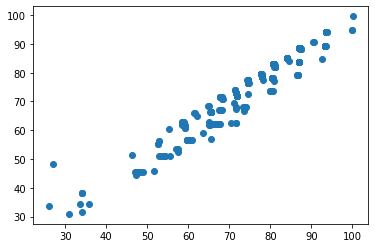

In [15]:
plt.scatter(y_predict,y_test)

In [16]:
from sklearn.metrics import mean_squared_error
print('mse:%.2f'%mean_squared_error(y_predict,y_test))

mse:9.78


In [17]:
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor(n_estimators=10,random_state=0,n_jobs=-1)
rf.fit(x_train,y_train)

C:\Users\SHANTANU\AppData\Local\Temp/ipykernel_20828/745586064.py:3: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  rf.fit(x_train,y_train)


RandomForestRegressor(n_estimators=10, n_jobs=-1, random_state=0)

In [18]:
y_pred=rf.predict(x_test)
y_pred

array([43.754, 78.66 , 45.48 , 79.64 , 94.   , 94.   , 66.44 , 88.56 ,
       82.94 , 55.2  , 79.64 , 56.72 , 60.698, 73.04 , 77.32 , 56.72 ,
       71.7  , 45.48 , 89.32 , 71.7  , 88.56 , 88.56 , 88.56 , 78.26 ,
       79.64 , 91.03 , 88.56 , 82.94 , 42.434, 82.94 , 78.26 , 63.082,
       77.32 , 83.556, 67.398, 88.56 , 83.88 , 85.26 , 66.642, 79.2  ,
       89.32 , 73.58 , 82.94 , 66.312, 88.56 , 56.72 , 66.312, 56.814,
       91.03 , 71.612, 82.94 , 76.34 , 82.94 , 83.88 , 94.   , 47.722,
       83.88 , 82.94 , 79.2  , 62.34 , 94.   , 82.94 , 77.32 , 94.   ,
       88.572, 83.88 , 67.046, 66.44 , 59.154, 86.24 , 82.94 , 82.94 ,
       85.26 , 78.26 , 78.26 , 78.66 , 51.1  , 72.532, 71.7  , 66.44 ,
       79.2  , 77.32 , 85.26 , 82.94 , 51.1  , 70.72 , 66.44 , 94.   ,
       82.94 , 76.34 , 89.32 , 94.   , 78.87 , 76.34 , 74.124, 83.88 ,
       73.58 , 82.94 , 60.82 , 88.56 , 82.94 , 88.56 , 88.56 , 62.17 ,
       51.1  , 88.38 , 81.96 , 88.56 , 88.56 , 81.38 , 53.1  , 83.88 ,
      

In [20]:
y_test

,wqi
1292,38.34
1310,78.66
960,45.48
107,79.64
1556,94.00
...,...
360,76.34
1801,67.96
1388,94.00
1026,78.26


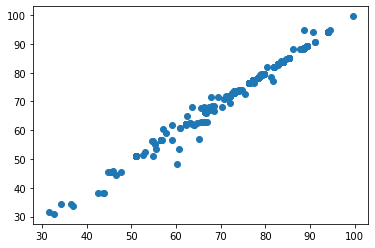

In [21]:
plt.scatter(y_pred,y_test)

##Acuracy

In [22]:
r2_score(y_test,y_pred)

0.99082508375938

In [23]:
from sklearn.metrics import mean_squared_error
print('mse:%.2f'%mean_squared_error(y_pred,y_test))

mse:1.65


array([52.086])

In [ ]:
!pip install streamlit

Streamlit

In [ ]:
rf=RandomForestRegressor(n_estimators=10,random_state=0,n_jobs=-1)
rf.fit(x_train,y_train)

In [ ]:
import pickle 
pickle_out = open("classifier.pkl", mode = "wb") 
pickle.dump(rfy, pickle_out) 
pickle_out.close()

In [ ]:
%%writefile app.py 

import pickle
import streamlit as st
from streamlit_option_menu import option_menu
 
# loading the trained model
pickle_in = open('classifier.pkl', 'rb') 
classifier = pickle.load(pickle_in)
 
@st.cache_data()
  
# defining the function which will make the prediction using the data which the user inputs 
def prediction(do, ph, co, bod, na, tc, pH, bdo, ec):   
    import pickle
    import streamlit as st
    pickle_in = open('classifier.pkl', 'rb') 
    classifier = pickle.load(pickle_in)
    # Making predictions 
    prediction = classifier.predict( 
        [[do, ph, co, bod, na, tc, pH, bdo, ec]])      
  
# this is the main function in which we define our webpage  
def main():       
    # front end elements of the web page 
    html_temp = """ 
    <div style ="background-color:yellow;padding:13px"> 
    <h1 style ="color:black;text-align:center;">Urban Land Cover Prediction ML App</h1> 
    </div> 
    """
      
    # display the front end aspect
    st.markdown(html_temp, unsafe_allow_html = True) 

        
    # following lines create boxes in which user can enter data required to make prediction 
    do = st.number_input('Border Index')
    ph = st.number_input('Area') 
    co = st.number_input("Round") 
    bod = st.number_input("Bright")
    na = st.number_input("Compact")
    tc = st.number_input("ShpIndx")
    pH = st.number_input("")
    bdo = st.number_input("")
    ec= st.number_input("")
    
    result =""
    
    # when 'Predict' is clicked, make the prediction and store it 
    if st.button("Predict"): 
        result = prediction(BrdIndx, Area, Round, Bright, Compact, ShpIndx, Mean_G, Mean_R,Mean_NIR,SD_G,SD_R,SD_NIR,LW,GLCM1,Rect,GLCM2,Dens,Assym,NDVI,BordLngth,GLCM3)
        st.success('Your Class is {}'.format(result))
        print(result)
     
if __name__=='__main__': 
    main()

In [ ]:
!streamlit run app.py